# TP 5 | Graphes avec NetworkX et ipycytoscape

**Dataset :** [Toy Network Datasets](https://www.kaggle.com/datasets/mateuscco/toy-network-datasets) | 5 réseaux au format Pajek (`.net`).

**Graphe étudié :** `NetScience.net`, réseau de **co-auteurs** de scientifiques travaillant sur les réseaux (M. Newman, 2006). Un nœud = un chercheur, une arête = au moins un article écrit ensemble.

| # | Tâche |
|---|-------|
| 1 | Charger un graphe `.net` (Pajek) avec NetworkX |
| 2 | Afficher le nombre de nœuds et d'arêtes |
| 3 | Visualiser le graphe avec matplotlib |
| 4 | Calculer le degré de chaque nœud |
| 5 | Tracer la distribution des degrés |
| 6 | Visualiser avec ipycytoscape |

## 0. Configuration

Dépendances : `networkx`, `matplotlib`, `pandas`, `scipy` (utilisé par certains algorithmes de NetworkX), `ipycytoscape`, `kagglehub`.

In [2]:
from pathlib import Path

import ipycytoscape
import kagglehub
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

SEED = 42
plt.rcParams["figure.dpi"] = 100
print(f"NetworkX {nx.__version__} | ipycytoscape {ipycytoscape.__version__}")

NetworkX 3.6.1 | ipycytoscape 1.3.3


---
## 1. Charger un graphe Pajek avec NetworkX

Le format **Pajek** est un fichier texte en deux blocs :
```
*Vertices 3            <- nombre de nœuds
1 "Alice"              <- numéro et nom de chaque nœud
2 "Bob"
3 "Carol"
*Edges                 <- liste des arêtes (non orientées) ; *Arcs pour un graphe orienté
1 2                    <- Alice - Bob
2 3 1.0                <- poids optionnel
```

In [3]:
path = kagglehub.dataset_download("mateuscco/toy-network-datasets")
DATA_DIR = Path(path)

rows = []
for f in sorted(DATA_DIR.glob("*.net")):
    g = nx.read_pajek(f)
    rows.append({"fichier": f.name, "type": type(g).__name__, "nœuds": g.number_of_nodes(), "arêtes": g.number_of_edges()})
pd.DataFrame(rows)

,fichier,type,nœuds,arêtes
0,26KeroNetwork.net,MultiGraph,135,318
1,imports_manufactures.net,MultiDiGraph,80,998
2,NetScience.net,MultiGraph,1589,2742
3,Ring25.net,MultiGraph,25,50
4,YeastS.net,MultiGraph,2361,7182


`nx.read_pajek` renvoie toujours un **multigraphe** (`MultiGraph`, ou `MultiDiGraph` si le fichier contient des `*Arcs`), qui autorise plusieurs arêtes entre deux mêmes nœuds. On le convertit en graphe simple `nx.Graph` pour les analyses.

In [4]:
NET_FILE = DATA_DIR / "NetScience.net"

print("Début du fichier :")
with open(NET_FILE, encoding="utf-8", errors="replace") as fh:
    lines = fh.readlines()
start = next(i for i, l in enumerate(lines) if l.lower().startswith("*vertices"))
print("".join(lines[start:start + 4]))

G_multi = nx.read_pajek(NET_FILE)
G = nx.Graph(G_multi)                         # graphe simple, non orienté
print("Type chargé :", type(G_multi).__name__, "-> converti en", type(G).__name__)
print("Exemples de nœuds :", list(G.nodes)[:5])

Début du fichier :
*vertices 1589
1 "Kuperman, M"
2 "Acebron, J"
3 "Bonilla, L"

Type chargé : MultiGraph -> converti en Graph
Exemples de nœuds : ['Kuperman, M', 'Acebron, J', 'Bonilla, L', 'Perezvicente, C', 'Ritort, F']


---
## 2. Nombre de nœuds et d'arêtes

In [5]:
n, m = G.number_of_nodes(), G.number_of_edges()
components = list(nx.connected_components(G))
largest = max(components, key=len)

print(f"Nœuds                 : {n}")
print(f"Arêtes                : {m}")
print(f"Densité               : {nx.density(G):.5f}  (= 2m / (n(n-1)), part des liens possibles réellement présents)")
print(f"Composantes connexes  : {len(components)}")
print(f"Plus grande composante: {len(largest)} nœuds ({len(largest) / n:.0%} du graphe)")
print(f"Nœuds isolés          : {nx.number_of_isolates(G)}")

Nœuds                 : 1589
Arêtes                : 2742
Densité               : 0.00217  (= 2m / (n(n-1)), part des liens possibles réellement présents)
Composantes connexes  : 396
Plus grande composante: 379 nœuds (24% du graphe)
Nœuds isolés          : 128


Le graphe est très **peu dense** (0,2 % des liens possibles) et **fragmenté** en de nombreux petits groupes : chaque composante correspond à une équipe ou un groupe de chercheurs qui publient ensemble. La plus grande composante réunit environ un quart des chercheurs.

---
## 3. Visualisation avec matplotlib

Un graphe n'a pas de position naturelle : il faut choisir une **disposition** (*layout*). `spring_layout` simule des ressorts : les nœuds reliés s'attirent, les autres se repoussent. Les groupes connectés apparaissent donc regroupés. `seed` fixe le résultat.

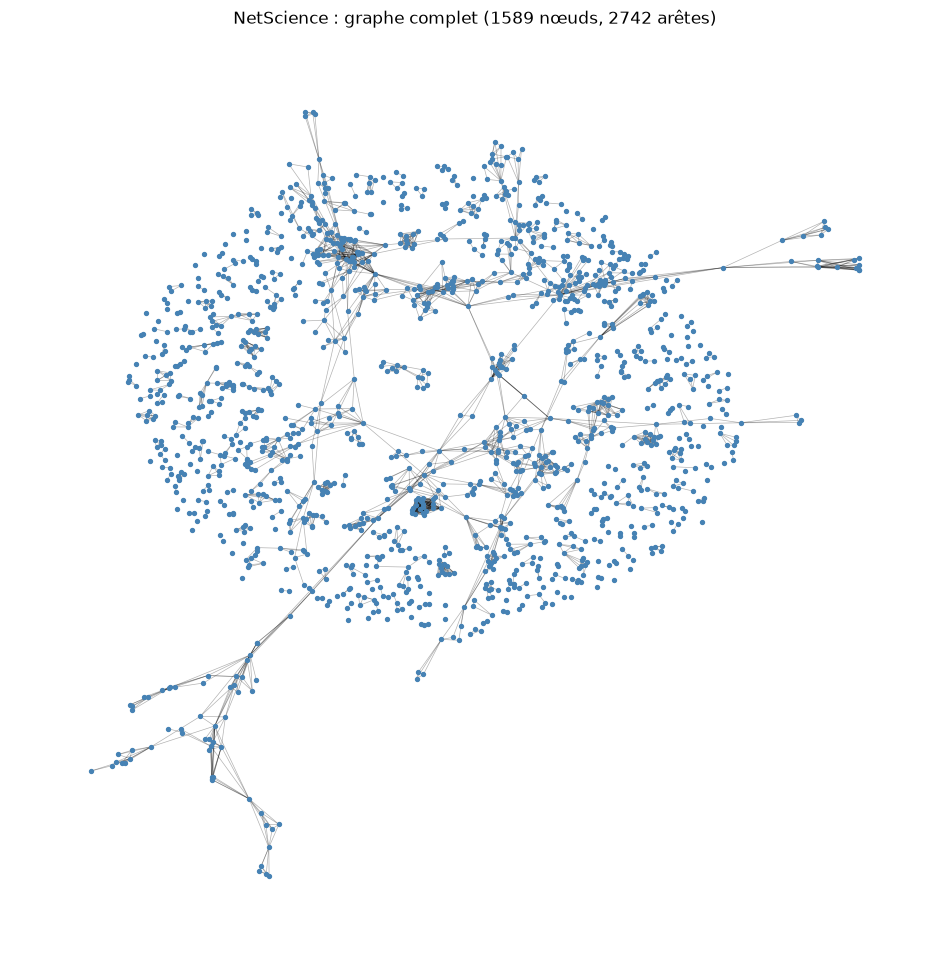

In [6]:
pos = nx.spring_layout(G, seed=SEED, k=0.08)

fig, ax = plt.subplots(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=0.5)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=8, node_color="steelblue")
ax.set_title(f"NetScience : graphe complet ({n} nœuds, {m} arêtes)")
ax.axis("off")
plt.show()

Le graphe complet montre surtout sa structure globale : une grande composante au centre et de nombreux petits groupes isolés autour. Pour lire les détails, on zoome sur la **plus grande composante**, en rendant la taille des nœuds proportionnelle à leur degré et en nommant les 10 chercheurs les plus connectés.

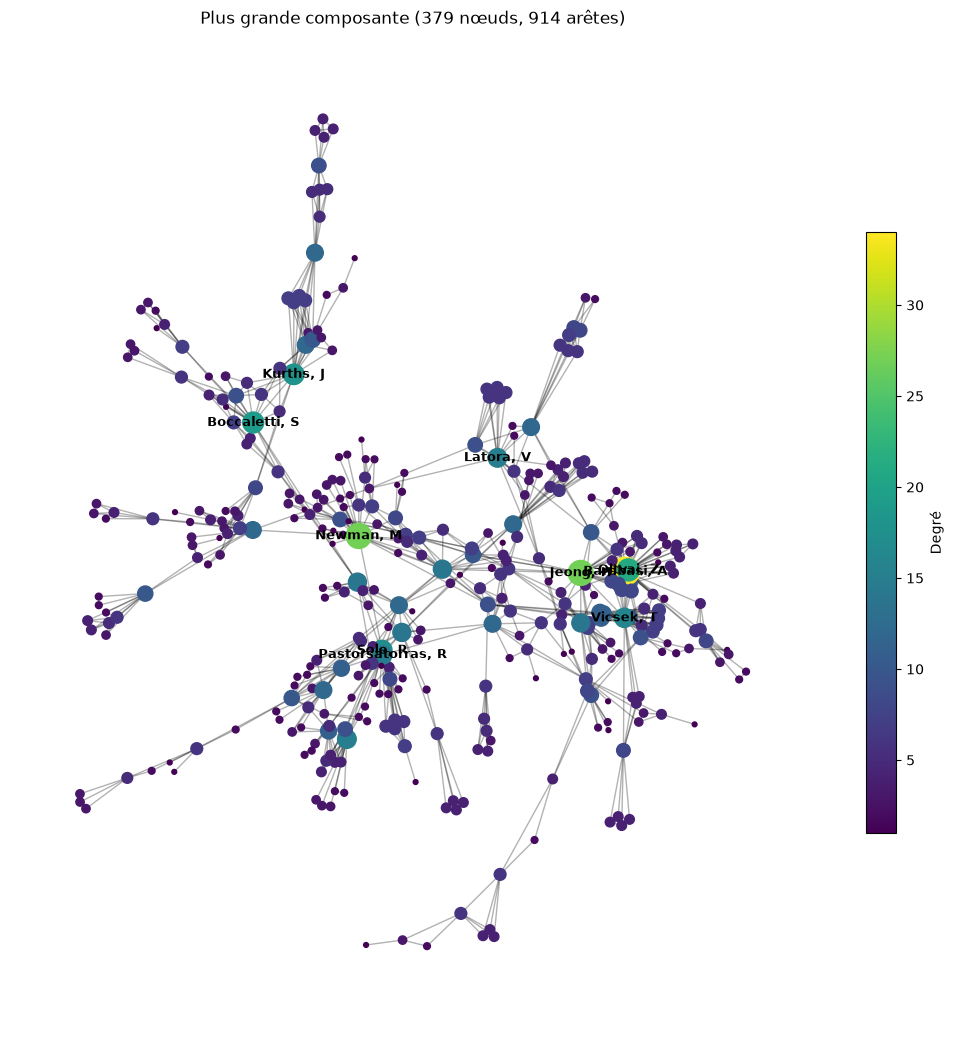

In [7]:
H = G.subgraph(largest).copy()
pos_h = nx.spring_layout(H, seed=SEED)
deg_h = dict(H.degree())
top10 = sorted(deg_h, key=deg_h.get, reverse=True)[:10]

fig, ax = plt.subplots(figsize=(13, 13))
nx.draw_networkx_edges(H, pos_h, ax=ax, alpha=0.3)
nodes = nx.draw_networkx_nodes(H, pos_h, ax=ax, node_size=[deg_h[v] * 12 for v in H],
                               node_color=[deg_h[v] for v in H], cmap="viridis")
nx.draw_networkx_labels(H, pos_h, labels={v: v for v in top10}, ax=ax, font_size=9, font_weight="bold")
fig.colorbar(nodes, ax=ax, shrink=0.6, label="Degré")
ax.set_title(f"Plus grande composante ({H.number_of_nodes()} nœuds, {H.number_of_edges()} arêtes)")
ax.axis("off")
plt.show()

---
## 4. Degré de chaque nœud

Le **degré** d'un nœud est son nombre de voisins : ici, le nombre de **co-auteurs** distincts d'un chercheur.

Propriété à vérifier : chaque arête touche 2 nœuds, donc $\sum \text{degrés} = 2m$ et le degré moyen vaut $2m / n$.

In [8]:
degrees = dict(G.degree())
deg = pd.Series(degrees, name="degré").sort_values(ascending=False)

print(f"Somme des degrés : {deg.sum()}  |  2 x arêtes : {2 * m}")
print(f"Degré moyen      : {deg.mean():.2f}  (2m / n = {2 * m / n:.2f})")
print(f"Degré médian     : {deg.median():.0f}")
print(f"Degré min / max  : {deg.min()} / {deg.max()}")
print("\nLes 10 chercheurs avec le plus de co-auteurs :")
print(deg.head(10).to_string())

Somme des degrés : 5484  |  2 x arêtes : 5484
Degré moyen      : 3.45  (2m / n = 3.45)
Degré médian     : 3
Degré min / max  : 0 / 34

Les 10 chercheurs avec le plus de co-auteurs :
Barabasi, A     34
Newman, M       27
Jeong, H        27
Oltvai, Z       21
Mansfield, T    20
Uetz, P         20
Young, M        20
Cagney, G       20
Giot, L         19
Rothberg, J     19


Le nœud de plus haut degré est **Barabási**, auteur du modèle de réseaux « sans échelle » : cohérent pour un réseau de chercheurs en science des réseaux. Le degré moyen (3,5) est bien plus proche du minimum que du maximum (34) : quelques nœuds très connectés tirent la moyenne vers le haut.

---
## 5. Distribution des degrés

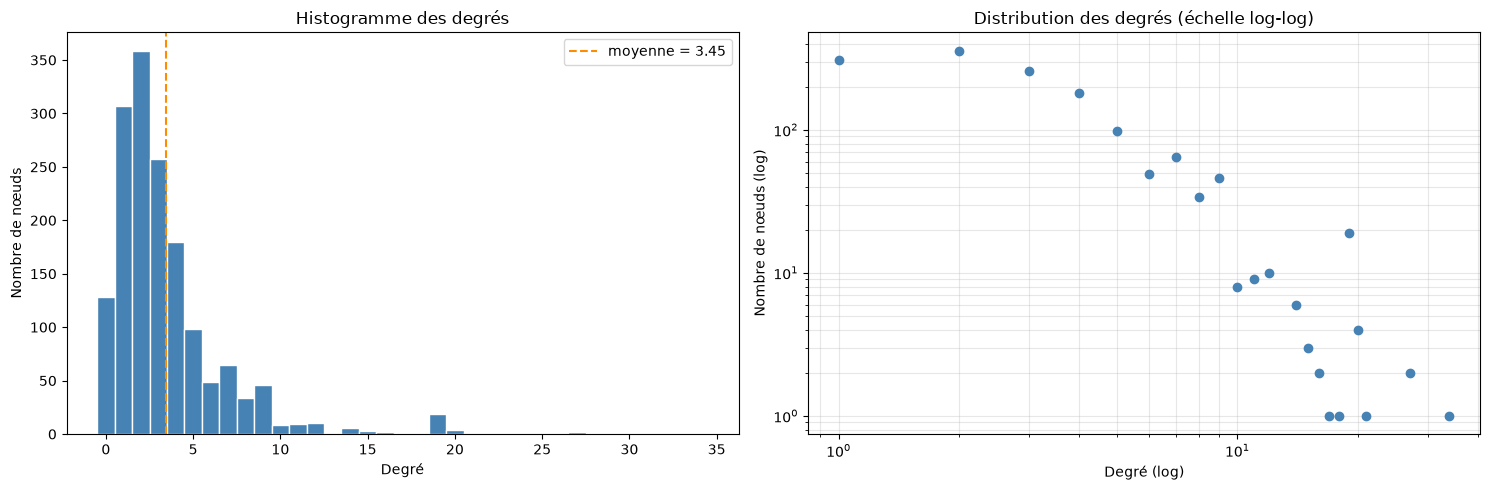

Nœuds de degré <= 3 : 66% | nœuds de degré >= 15 : 34


In [9]:
counts = deg.value_counts().sort_index()          # nombre de nœuds pour chaque valeur de degré

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bins = np.arange(deg.min(), deg.max() + 2) - 0.5  # une barre par valeur entière de degré
axes[0].hist(deg, bins=bins, color="steelblue", edgecolor="white")
axes[0].axvline(deg.mean(), color="darkorange", linestyle="--", label=f"moyenne = {deg.mean():.2f}")
axes[0].set_title("Histogramme des degrés")
axes[0].set_xlabel("Degré")
axes[0].set_ylabel("Nombre de nœuds")
axes[0].legend()

axes[1].loglog(counts.index, counts.values, "o", color="steelblue")
axes[1].set_title("Distribution des degrés (échelle log-log)")
axes[1].set_xlabel("Degré (log)")
axes[1].set_ylabel("Nombre de nœuds (log)")
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

print(f"Nœuds de degré <= 3 : {(deg <= 3).mean():.0%} | nœuds de degré >= 15 : {(deg >= 15).sum()}")

**Lecture :**
- La distribution est très **asymétrique** : la grande majorité des chercheurs ont peu de co-auteurs, et seuls quelques-uns en ont beaucoup. On parle de distribution à **queue lourde**.
- En échelle log-log (les 128 nœuds isolés, de degré 0, n'y figurent pas car log(0) n'existe pas), les points décroissent approximativement selon une **droite** à partir du degré 2 : signe d'une loi de puissance $P(k) \propto k^{-\gamma}$, typique des réseaux réels (réseaux sociaux, web, collaborations).
- Le **pic isolé au degré 19** a une explication concrète : un article signé par **20 auteurs** (Uetz, Giot, Cagney...) relie chacun d'eux aux 19 autres. Ils forment une **clique** de 20 nœuds, la plus grande du graphe, d'où ce groupe de nœuds de degré 19 ou 20. Cette équipe forme sa propre composante, en dehors de la plus grande composante.
- Les nœuds de fort degré sont des **hubs** : ils relient des groupes qui, sans eux, seraient séparés.

---
## 6. Visualisation interactive avec ipycytoscape

`ipycytoscape` affiche le graphe dans un **widget interactif** : zoom, déplacement, glisser-déposer des nœuds.

**Remarques :**
- Le widget n'apparaît que dans un notebook **exécuté** (Jupyter Lab, VS Code), pas sur GitHub.
- On affiche la plus grande composante (379 nœuds) : le graphe complet serait lent et illisible.
- Piège : les nœuds lus depuis Pajek ont un attribut `id` (leur numéro dans le fichier). ipycytoscape l'utiliserait comme identifiant au lieu du nom, ce qui **dupliquerait** tous les nœuds. On nettoie donc les attributs avant la conversion.

In [11]:
H_cy = nx.Graph()
for v in H.nodes:
    H_cy.add_node(v, label=v, degree=deg_h[v], top="yes" if v in top10 else "no")
H_cy.add_edges_from(H.edges)

cyto = ipycytoscape.CytoscapeWidget()
cyto.graph.add_graph_from_networkx(H_cy)
print(f"Widget : {len(cyto.graph.nodes)} nœuds, {len(cyto.graph.edges)} arêtes")

cyto.set_layout(name="cose", animate=False, randomize=False)
cyto.set_style([
    {"selector": "node", "style": {
        "width": "mapData(degree, 1, 34, 8, 45)",           # taille proportionnelle au degré
        "height": "mapData(degree, 1, 34, 8, 45)",
        "background-color": "mapData(degree, 1, 34, #9ecae1, #08306b)",
    }},
    {"selector": "node[top = 'yes']", "style": {             # noms des 10 principaux hubs
        "label": "data(label)", "font-size": 14, "color": "#d94801", "font-weight": "bold",
    }},
    {"selector": "edge", "style": {"width": 1, "line-color": "#bbbbbb"}},
])
cyto.layout.height = "700px"
cyto

Widget : 379 nœuds, 914 arêtes


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'animate': False, 'randomize': False}, cytoscape_style=[{'se…

Dans le widget : molette pour zoomer, glisser le fond pour se déplacer, glisser un nœud pour le déplacer. La disposition `cose` (force-directed, comme `spring_layout`) fait ressortir les communautés de chercheurs reliées entre elles par les hubs.

---
## Conclusion

| Notion | À retenir |
|---|---|
| Format Pajek | `*Vertices` puis `*Edges` (non orienté) ou `*Arcs` (orienté) |
| Chargement | `nx.read_pajek` renvoie un multigraphe ; `nx.Graph(...)` pour un graphe simple |
| Taille | `number_of_nodes`, `number_of_edges`, densité, composantes connexes |
| Visualisation | un layout calcule des positions ; `spring_layout` rapproche les nœuds reliés |
| Degré | nombre de voisins ; somme des degrés = 2 x nombre d'arêtes |
| Distribution | queue lourde, quasi loi de puissance : beaucoup de petits degrés, quelques hubs |
| ipycytoscape | visualisation interactive ; nettoyer l'attribut `id` issu de Pajek |